<a href="https://colab.research.google.com/github/Aditya-Raj-Kaushik/Vision-Transformer/blob/main/Vision_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import random

In [56]:
torch.__version__

'2.10.0+cu128'

In [57]:
torchvision.__version__

'0.25.0+cu128'

In [58]:
!nvidia-smi

Tue May 26 07:29:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   60C    P0             29W /   70W |     319MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [59]:
torch.cuda.is_available()

True

In [60]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [61]:
print(f"Using Device: {device}")

Using Device: cuda


In [62]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
random.seed(42)

In [63]:
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 3e-4
PATCH_SIZE = 4
NUM_CLASSES = 10
IMAGE_SIZE = 32
CHANNELS = 3
EMBED_DIM = 256
NUM_HEADS = 8
DEPTH = 6
MLP_DIM = 512
DROP_RATE = 0.1

In [64]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5), (0.5))
])

In [65]:
train_data = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=transform
)

In [66]:
test_data = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=transform
)

In [67]:
train_data

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=0.5, std=0.5)
           )

In [68]:
len(train_data)

50000

In [69]:
len(test_data)

10000

In [70]:
train_loader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=True)

In [71]:
print(f"Dataloader: {train_loader, test_loader}")
print(f"Length of Trainloader: {len(train_loader)}")
print(f"Length of Testloader: {len(test_loader)}")

Dataloader: (<torch.utils.data.dataloader.DataLoader object at 0x785889c967e0>, <torch.utils.data.dataloader.DataLoader object at 0x785889c92840>)
Length of Trainloader: 391
Length of Testloader: 79


In [72]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super().__init__()

        self.patch_size = patch_size

        self.proj = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        x = self.proj(x)

        x = x.flatten(2)

        x = x.transpose(1, 2)

        return x


In [73]:
class MLP(nn.Module):

    def __init__(self, in_features, hidden_features, out_features, drop_rate=0.1):

        super().__init__()

        self.fc1 = nn.Linear(
            in_features=in_features,
            out_features=hidden_features
        )

        self.fc2 = nn.Linear(
            in_features=hidden_features,
            out_features=out_features
        )

        self.drop = nn.Dropout(drop_rate)

    def forward(self, x):

        x = self.drop(F.gelu(self.fc1(x)))

        x = self.drop(self.fc2(x))

        return x

In [74]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, drop_rate):
        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)

        self.attn = nn.MultiheadAttention(
            embed_dim,
            num_heads,
            dropout=drop_rate,
            batch_first=True
        )

        self.norm2 = nn.LayerNorm(embed_dim)

        self.mlp = MLP(
    in_features=embed_dim,
    hidden_features=mlp_dim,
    out_features=embed_dim,
    drop_rate=drop_rate
)

    def forward(self, x):
        x = x + self.attn(
            self.norm1(x),
            self.norm1(x),
            self.norm1(x)
        )[0]

        x = x + self.mlp(self.norm2(x))

        return x

In [75]:
class VisionTransformer(nn.Module):
    def __init__(
        self,
        img_size,
        patch_size,
        in_channels,
        num_classes,
        embed_dim,
        depth,
        num_heads,
        mlp_dim,
        drop_rate
    ):
        super().__init__()

        self.patch_embed = PatchEmbedding(
            img_size,
            patch_size,
            in_channels,
            embed_dim
        )

        self.encoder = nn.Sequential(
            *[
                TransformerEncoderLayer(
                    embed_dim,
                    num_heads,
                    mlp_dim,
                    drop_rate
                )
                for _ in range(depth)
            ]
        )

        self.norm = nn.LayerNorm(embed_dim)

        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.patch_embed(x)

        x = self.encoder(x)

        x = self.norm(x)

        cls_token = x[:, 0]

        return self.head(cls_token)

In [76]:
model = VisionTransformer(
    IMAGE_SIZE, PATCH_SIZE, CHANNELS, NUM_CLASSES, EMBED_DIM, DEPTH, NUM_HEADS, MLP_DIM, DROP_RATE
).to(device)

In [77]:
model

VisionTransformer(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(3, 256, kernel_size=(4, 4), stride=(4, 4))
  )
  (encoder): Sequential(
    (0): TransformerEncoderLayer(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=256, out_features=512, bias=True)
        (fc2): Linear(in_features=512, out_features=256, bias=True)
        (drop): Dropout(p=0.1, inplace=False)
      )
    )
    (1): TransformerEncoderLayer(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP(
 

In [78]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=LEARNING_RATE)

In [79]:
criterion

CrossEntropyLoss()

In [80]:
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0003
    maximize: False
    weight_decay: 0
)

In [81]:
def train(model, loader, optimizer, criterion):
    model.train()

    total_loss, correct = 0, 0

    for x,y in loader:
      x,y = x.to(device), y.to(device)

      optimizer.zero_grad()

      y_pred = model(x)

      loss = criterion(y_pred, y)

      loss.backward()

      optimizer.step()

      total_loss += loss.item()*x.size(0)

      correct += (y_pred.argmax(1) == y).sum().item()

    return total_loss/len(loader.dataset), correct/len(loader.dataset)

In [82]:
def evaluate(model, loader):
  model.eval()
  correct = 0
  with torch.inference_mode():
    for x,y in loader:
      x,y = x.to(device), y.to(device)
      y_pred = model(x)
      correct += (y_pred.argmax(dim=1) == y).sum().item()
  return correct/len(loader.dataset)

In [83]:
from tqdm.auto import tqdm

In [84]:
train_accuracies, test_accuracies = [], []

for epoch in tqdm(range(EPOCHS)):

    train_loss, train_acc = train(
        model,
        train_loader,
        optimizer,
        criterion
    )

    test_acc = evaluate(
        model,
        test_loader
    )

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(
        f"Epoch: {epoch+1}/{EPOCHS}, "
        f"Train loss: {train_loss:.4f}, "
        f"Train acc: {train_acc:.4f}%, "
        f"Test acc: {test_acc:.4f}%"
    )

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1/10, Train loss: 1.7298, Train acc: 0.3614%, Test acc: 0.4317%
Epoch: 2/10, Train loss: 1.4370, Train acc: 0.4784%, Test acc: 0.4937%
Epoch: 3/10, Train loss: 1.3089, Train acc: 0.5262%, Test acc: 0.5361%
Epoch: 4/10, Train loss: 1.2245, Train acc: 0.5609%, Test acc: 0.5540%
Epoch: 5/10, Train loss: 1.1540, Train acc: 0.5857%, Test acc: 0.5641%
Epoch: 6/10, Train loss: 1.1012, Train acc: 0.6028%, Test acc: 0.5360%
Epoch: 7/10, Train loss: 1.0515, Train acc: 0.6217%, Test acc: 0.5648%
Epoch: 8/10, Train loss: 1.0052, Train acc: 0.6391%, Test acc: 0.5888%
Epoch: 9/10, Train loss: 0.9530, Train acc: 0.6596%, Test acc: 0.5823%
Epoch: 10/10, Train loss: 0.9028, Train acc: 0.6756%, Test acc: 0.5845%


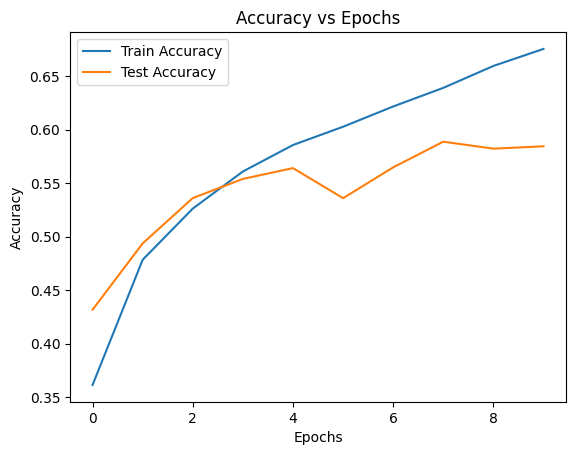

In [85]:
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs")
plt.legend()
plt.show()